# Diffusion Kernel Experiment

Systematic comparison of three affinity matrix constructions within a spectral-ALC clustering pipeline.

**Pipeline:** raw data → affinity matrix A → Laplacian L → eigendecomposition → eigenvector embedding U → ALC → cluster labels

**Affinity types compared:**
- `gaussian`  — fully connected Gaussian kernel
- `knn`       — k-nearest-neighbour Gaussian kernel
- `diffusion` — diffusion kernel (matrix exponential of k-NN affinity)

**Laplacians:** unnormalised, symmetrically normalised (SYM), random-walk normalised (RW)

**Metric:** Adjusted Rand Index (ARI) against ground-truth labels

Seeds: dataset generation = 42, ALC = 6.

---
## Section 1: Imports and Utility Functions

In [1]:
import sys
import os
import time
import warnings

# Add project root to path (this notebook lives in <root>/notebooks/)
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.linalg import eigh, eig, expm
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score
from tqdm.notebook import tqdm

from clustering.alc import ALCAdapter
from data.generators import make_blobs_convex, make_rings, make_two_moons

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

print("Imports complete.")

Imports complete.


In [2]:
# ── Utility functions ─────────────────────────────────────────────────────────

def dist_mat(X):
    """Return the pairwise Euclidean distance matrix for data matrix X."""
    return cdist(X, X, "euclidean")


def check_psd(M, name="Matrix", quiet=False):
    """
    Check whether M is symmetric and positive semi-definite.

    Parameters
    ----------
    M     : ndarray, square matrix to inspect
    name  : str, label used in the printed summary
    quiet : bool, suppress printed output when True

    Returns
    -------
    dict with keys: is_symmetric, is_psd, min_eigenvalue, n_negative_eigenvalues
    """
    is_symmetric = bool(np.allclose(M, M.T))
    eigenvalues  = np.linalg.eigvalsh(M)
    is_psd       = bool(np.all(eigenvalues >= -1e-10))
    n_neg        = int(np.sum(eigenvalues < -1e-10))

    result = {
        "is_symmetric":           is_symmetric,
        "is_psd":                 is_psd,
        "min_eigenvalue":         float(eigenvalues.min()),
        "n_negative_eigenvalues": n_neg,
    }

    if not quiet:
        print(f"{name}: symmetric={is_symmetric}, PSD={is_psd}, "
              f"min_eig={eigenvalues.min():.4e}, n_neg={n_neg}")

    return result


def project_to_psd(A):
    """
    Project A onto the PSD cone by clipping negative eigenvalues to zero.

    Returns the nearest PSD matrix (in Frobenius norm) to A.
    """
    vals, vecs = np.linalg.eigh(A)
    vals_clipped = np.maximum(vals, 0.0)
    A_psd = vecs @ np.diag(vals_clipped) @ vecs.T
    A_psd = (A_psd + A_psd.T) / 2   # enforce numerical symmetry
    return A_psd


print("Utility functions defined.")

Utility functions defined.


---
## Section 2: Affinity Matrix Constructors

All three constructors accept a precomputed pairwise distance matrix and return an affinity matrix A.
The diagonal is **kept** (not zeroed) to preserve the PSD property of the Gaussian kernel.

In [3]:
# ── Affinity constructors ──────────────────────────────────────────────────────

def affinity_gaussian(dist_matrix, sigma):
    """
    Fully connected Gaussian kernel affinity matrix.

    A[i,j] = exp(-dist[i,j]^2 / (2 * sigma^2)).
    Diagonal entries are exp(0) = 1 (self-similarity kept).
    """
    return np.exp(-dist_matrix**2 / (2.0 * sigma**2))


def affinity_knn(dist_matrix, k, sigma):
    """
    k-nearest-neighbour Gaussian affinity matrix.

    Connects each point to its k nearest neighbours with a Gaussian kernel
    weight. The mask is symmetrised via the OR rule so the graph is undirected.
    The diagonal is forced True to preserve self-similarity.

    Parameters
    ----------
    dist_matrix : ndarray (n, n)
    k           : int, number of nearest neighbours
    sigma       : float, Gaussian bandwidth
    """
    n = dist_matrix.shape[0]

    # Fallback: if k >= n-1 the graph is fully connected
    if k >= n - 1:
        return affinity_gaussian(dist_matrix, sigma)

    # Step 1: k nearest neighbours for each row (skip self at sorted index 0)
    nn_idx = np.argsort(dist_matrix, axis=1)[:, 1:k + 1]   # (n, k)

    # Step 2: build directed adjacency mask
    nn_mask = np.zeros((n, n), dtype=bool)
    rows = np.repeat(np.arange(n), k)
    nn_mask[rows, nn_idx.ravel()] = True

    # Step 3: symmetrise (OR rule → undirected graph)
    sym_mask = nn_mask | nn_mask.T

    # Step 4: keep self-similarity on the diagonal
    np.fill_diagonal(sym_mask, True)

    # Step 5: full Gaussian kernel
    W = np.exp(-dist_matrix**2 / (2.0 * sigma**2))

    # Step 6: apply mask
    return W * sym_mask


def affinity_diffusion(dist_matrix, k, sigma, t):
    """
    Diffusion kernel affinity matrix.

    Builds a k-NN Gaussian affinity A, projects onto the PSD cone, then
    computes K_t = expm(-t * A_psd) via the matrix exponential.

    Parameters
    ----------
    dist_matrix : ndarray (n, n)
    k           : int, number of nearest neighbours
    sigma       : float, Gaussian bandwidth
    t           : float, diffusion time (controls smoothing)

    Returns
    -------
    K_t : ndarray (n, n), diffusion kernel (approximately PSD)

    Note: expm is scipy.linalg.expm (true matrix exponential, not elementwise).
    """
    # Step 1: base k-NN affinity
    A_knn = affinity_knn(dist_matrix, k, sigma)

    # Step 2: project onto PSD cone
    A_psd = project_to_psd(A_knn)

    # Step 3: diffusion kernel via matrix exponential
    K_t = expm(-t * A_psd)

    # Step 4: symmetrise for numerical precision
    K_t = (K_t + K_t.T) / 2

    # Clip small negative entries (floating-point noise from expm)
    K_t = np.maximum(K_t, 0.0)

    return K_t


print("Affinity constructors defined.")

Affinity constructors defined.


---
## Section 3: Laplacian Constructor

Three Laplacian types:
- **unnorm**: L = D − A  (symmetric, PSD when A is non-negative)
- **sym**: L = I − D^{−1/2} A D^{−1/2}  (symmetric, real eigenvalues via `eigh`)
- **rw**: L = I − D^{−1} A  (asymmetric, may need real-part extraction from `eig`)

In [4]:
def build_laplacian(A, laplacian_type):
    """
    Construct a graph Laplacian from affinity matrix A.

    Parameters
    ----------
    A              : ndarray (n, n), symmetric affinity matrix
    laplacian_type : str, one of 'unnorm', 'sym', 'rw'

    Returns
    -------
    L            : ndarray (n, n)
    d            : ndarray (n,), degree vector
    is_symmetric : bool
    """
    d = A.sum(axis=1)
    n = len(d)
    I = np.eye(n)

    if laplacian_type == "unnorm":
        D = np.diag(d)
        L = D - A
        is_symmetric = True

    elif laplacian_type == "sym":
        d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
        D_inv_sqrt = np.diag(d_inv_sqrt)
        L = I - D_inv_sqrt @ A @ D_inv_sqrt
        is_symmetric = True

    elif laplacian_type == "rw":
        d_inv = 1.0 / np.maximum(d, 1e-12)
        D_inv = np.diag(d_inv)
        L = I - D_inv @ A
        is_symmetric = False

    else:
        raise ValueError(
            f"Unknown laplacian_type: {laplacian_type!r}. "
            f"Choose from 'unnorm', 'sym', 'rw'."
        )

    return L, d, is_symmetric


print("Laplacian constructor defined.")

Laplacian constructor defined.


---
## Section 4: Eigensolver and Spectral Embedding

- Symmetric Laplacians (unnorm, sym): `scipy.linalg.eigh` — real, sorted ascending, orthonormal.
- Asymmetric Laplacian (rw): `scipy.linalg.eig` — strip imaginary noise, sort manually.
- SYM Laplacian: apply Ng–Jordan–Weiss row normalisation after selecting eigenvectors.

In [ ]:
def spectral_embedding(L, r, is_symmetric, laplacian_type):
    """
    Compute the r-dimensional spectral embedding of Laplacian L.

    Parameters
    ----------
    L              : ndarray (n, n)
    r              : int, number of eigenvectors to retain
    is_symmetric   : bool, True → eigh; False → eig with real-part extraction
    laplacian_type : str, 'sym' triggers NJW row normalisation

    Returns
    -------
    U           : ndarray (n, r), spectral embedding
    eigenvalues : ndarray (r,), ascending eigenvalues
    """
    if is_symmetric:
        # eigh: guaranteed real, sorted ascending, orthonormal eigenvectors
        eigenvalues, eigenvectors = eigh(L)
    else:
        # eig: may return complex — strip imaginary noise then sort
        eigenvalues_c, eigenvectors_c = eig(L)
        eigenvalues  = eigenvalues_c.real
        eigenvectors = eigenvectors_c.real
        sort_idx     = np.argsort(eigenvalues)
        eigenvalues  = eigenvalues[sort_idx]
        eigenvectors = eigenvectors[:, sort_idx]

    # Select first r eigenvectors and eigenvalues (smallest eigenvalues)
    U = eigenvectors[:, :r]
    lambdas = eigenvalues[:r]

    # Ng-Jordan-Weiss row normalisation for the SYM Laplacian
    if laplacian_type == "sym":
        row_norms = np.sqrt(np.sum(U**2, axis=1, keepdims=True)) # check this 
        U = U / np.maximum(row_norms, 1e-12)

    return U, lambdas


print("spectral_embedding defined.")

spectral_embedding defined.


---
## Section 5: Single Experiment Runner

`run_single` chains all steps for one configuration: Laplacian → embedding → ALC → ARI.

**ALC note:** `ALCAdapter.fit_predict` expects an (n × n) correlation matrix directly —
it does **not** compute `corrcoef` internally. We call `np.corrcoef(U)` here before passing
to ALC. Near-constant eigenvectors (eigenvalue ≈ 0, zero variance → NaN in corrcoef) are
filtered out before that step.

In [ ]:
def run_single(A, laplacian_type, r, y_true, seed=6):
    """
    Run one full spectral-ALC experiment for a given affinity matrix.

    Parameters
    ----------
    A              : ndarray (n, n), affinity matrix
    laplacian_type : str, 'unnorm' | 'sym' | 'rw'
    r              : int, embedding dimension
    y_true         : ndarray (n,), ground-truth cluster labels
    seed           : int, random seed for ALC

    Returns
    -------
    dict: ari, n_clusters_found, delta_k, spectral_gap,
          laplacian_is_psd, laplacian_min_eigenvalue
    """
    q = len(np.unique(y_true))   # ground-truth number of clusters

    # Step 1: build Laplacian
    L, d, is_sym = build_laplacian(A, laplacian_type)

    # Step 2: PSD check on Laplacian (symmetric Laplacians only)
    if is_sym:
        lap_psd_info = check_psd(L, name=f"L_{laplacian_type}", quiet=True)
        lap_is_psd   = lap_psd_info["is_psd"]
        lap_min_eig  = lap_psd_info["min_eigenvalue"]
    else:
        lap_is_psd  = "N/A"
        lap_min_eig = np.nan

    # Step 3: spectral embedding
    # Fetch r+1 eigenvectors so that after filtering the constant eigenvector
    # (eigenvalue ≈ 0, near-zero variance → NaN in corrcoef) we still have r valid columns.
    U, eigenvalues = spectral_embedding(L, r, is_sym, laplacian_type)

    # Step 4: cluster with ALC
    # ALCAdapter.fit_predict takes an (n, n) correlation matrix — not the raw embedding.
    np.random.seed(seed)
    alc    = ALCAdapter()
    # Reconstruct: Phi_q @ Lambda_q @ Phi_q^T
    R_hat = U @ np.diag(eigenvalues) @ U.T

    # Rescale to unit diagonal — restore valid correlation matrix
    diag = np.sqrt(np.diag(R_hat))
    diag = np.where(diag == 0, 1, diag)  # guard against zero diagonal
    R_hat = R_hat / np.outer(diag, diag)

    # Clip to [-1, 1] to correct floating point violations
    R_hat = np.clip(R_hat, -1, 1)     
    labels = alc.fit_predict(C, cn=None) # cn=None → ALC infers cluster count

    # Step 5: evaluate
    ari              = adjusted_rand_score(y_true, labels)
    n_clusters_found = int(len(np.unique(labels)))

    # Step 6: spectral gap (λ_q − λ_{q-1}, 0-indexed)
    if len(eigenvalues) > q:
        spectral_gap = float(eigenvalues[q] - eigenvalues[q - 1])
    else:
        spectral_gap = np.nan

    return {
        "ari":                      ari,
        "n_clusters_found":         n_clusters_found,
        "delta_k":                  abs(n_clusters_found - q),
        "spectral_gap":             spectral_gap,
        "laplacian_is_psd":         lap_is_psd,
        "laplacian_min_eigenvalue": lap_min_eig,
    }


print("run_single defined.")

run_single defined.


---
## Section 6: Dataset Generation

| Dataset | Generator           | N   | Clusters | Dimensionality |
|---------|---------------------|-----|----------|----------------|
| blobs   | `make_blobs_convex` | 1200 | 7        | 5000           |
| circles | `make_rings`        | 1200 | 3        | 2              |
| moons   | `make_two_moons`    | 1200| 2        | 2              |

Datasets generated:
       blobs: X=(1200, 5000), classes=[0 1 2 3 4 5 6], n_clusters=7
     circles: X=(1200, 2), classes=[1 2 3], n_clusters=3
       moons: X=(1200, 2), classes=[0 1], n_clusters=2


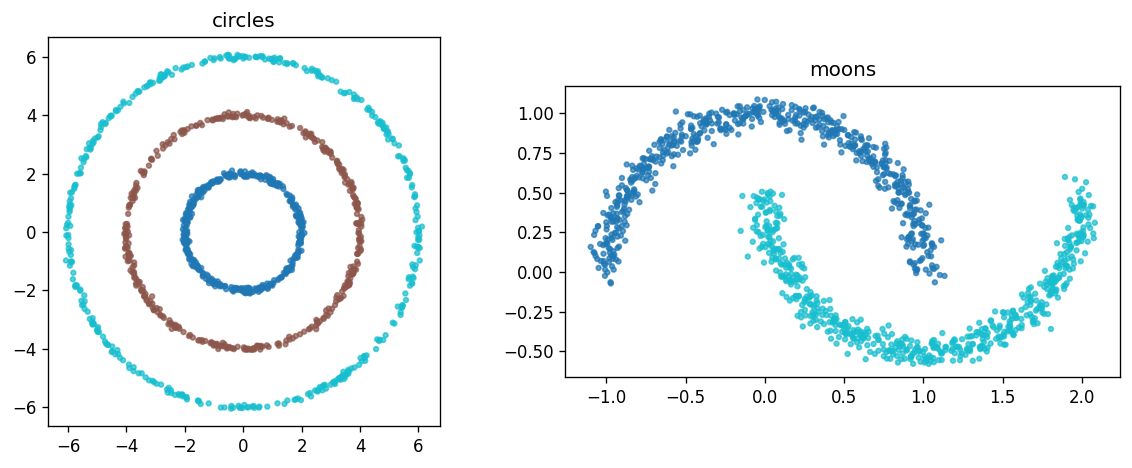

In [7]:
# ── Blobs: high-dimensional Gaussian clusters ─────────────────────────────────
X_blobs, y_blobs = make_blobs_convex(N=1200, num_clusters=7, n_features=5000, seed=42)
ds_blobs = {"name": "blobs", "X": X_blobs, "y": y_blobs, "n_clusters": 7}

# ── Circles: concentric rings ─────────────────────────────────────────────────
X_circles, y_circles = make_rings(n_points=1200, n_circles=3, noise_std=0.05, seed=42)
ds_circles = {"name": "circles", "X": X_circles, "y": y_circles, "n_clusters": 3}

# ── Moons: two interleaved half-circles ───────────────────────────────────────
X_moons, y_moons = make_two_moons(n_samples=1200, noise=0.05, seed=42)
ds_moons = {"name": "moons", "X": X_moons, "y": y_moons, "n_clusters": 2}

datasets = [ds_blobs, ds_circles, ds_moons]

print("Datasets generated:")
for ds in datasets:
    print(f"  {ds['name']:>10s}: X={ds['X'].shape}, "
          f"classes={np.unique(ds['y'])}, n_clusters={ds['n_clusters']}")

# Quick scatter for the 2-D datasets
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, ds in zip(axes, [ds_circles, ds_moons]):
    ax.scatter(ds["X"][:, 0], ds["X"][:, 1],
               c=ds["y"], cmap="tab10", s=8, alpha=0.7)
    ax.set_title(ds["name"])
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## Section 7: Parameter Grids

All three affinity types share the same `sigma_values` grid, allowing the bandwidth
parameter to be assessed independently of the structural parameter `k`.
- **Gaussian**: sweeps `(sigma)`.
- **k-NN**: sweeps `(sigma, k)` — the full Cartesian product.
- **Diffusion**: sweeps `(sigma, k, t)` — the full Cartesian product.

In [8]:
param_grids = {
    "blobs": {
        "sigma_values":    [10, 25, 50, 100, 200],
        "k_values":        [5, 10, 15, 25, 50],
        "t_values":        [0.1, 0.5, 1.0, 3.0, 5.0],
        "r_values":        [7, 10, 15, 25],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
    "circles": {
        "sigma_values":    [0.1, 0.25, 0.5, 1.0, 2.0],
        "k_values":        [5, 10, 15, 20, 30],
        "t_values":        [0.1, 0.5, 1.0, 3.0, 5.0],
        "r_values":        [3, 5, 10, 25],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
    "moons": {
        "sigma_values":    [0.1, 0.25, 0.5, 1.0, 2.0],
        "k_values":        [5, 10, 15, 20, 30],
        "t_values":        [0.1, 0.5, 1.0, 3.0, 5.0],
        "r_values":        [2, 4, 10, 25],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
}

# Configuration count summary
# k-NN sweeps (sigma, k); diffusion sweeps (sigma, k, t).
grand_total = 0
for ds_name, g in param_grids.items():
    n_lap   = len(g["laplacian_types"])
    n_r     = len(g["r_values"])
    n_sigma = len(g["sigma_values"])
    n_gauss = n_sigma * n_lap * n_r
    n_knn   = len(g["k_values"]) * n_sigma * n_lap * n_r
    n_diff  = len(g["k_values"]) * n_sigma * len(g["t_values"]) * n_lap * n_r
    ds_total = n_gauss + n_knn + n_diff
    grand_total += ds_total
    print(f"{ds_name:>10s}: gaussian={n_gauss:4d}  knn={n_knn:5d}  "
          f"diffusion={n_diff:5d}  →  {ds_total:5d} total")

print(f"\nTotal configurations across all datasets: {grand_total}")

     blobs: gaussian=  60  knn=  300  diffusion= 1500  →   1860 total
   circles: gaussian=  60  knn=  300  diffusion= 1500  →   1860 total
     moons: gaussian=  60  knn=  300  diffusion= 1500  →   1860 total

Total configurations across all datasets: 5580


---
## Section 8: Main Experiment Loop

Each `run_single` call is wrapped in `try/except` — a single numerical failure will not abort
the sweep. The diffusion kernel uses `scipy.linalg.expm` (O(n³)), so timing is printed after
the first call to give a runtime estimate.

In [9]:
# Pre-compute distance matrices (done once per dataset — reused across all affinities)
dist_matrices = {}
print("Computing distance matrices...")
for ds in datasets:
    t0 = time.time()
    dist_matrices[ds["name"]] = dist_mat(ds["X"])
    print(f"  {ds['name']:>10s}: {time.time() - t0:.2f}s")

Computing distance matrices...
       blobs: 1.93s
     circles: 0.00s
       moons: 0.00s


In [10]:
results = []

print(f"Starting sweep over {grand_total} configurations...\n")

for ds in tqdm(datasets, desc="Datasets"):
    name = ds["name"]
    y    = ds["y"]
    g    = param_grids[name]
    D    = dist_matrices[name]

    sigma_values    = g["sigma_values"]
    k_values        = g["k_values"]
    t_values        = g["t_values"]
    r_values        = g["r_values"]
    laplacian_types = g["laplacian_types"]

    # ── Affinity type 1: Gaussian ──────────────────────────────────────────────
    for sigma in tqdm(sigma_values, desc=f"{name}/gaussian", leave=False):
        A       = affinity_gaussian(D, sigma)
        aff_psd = check_psd(A, name=f"gauss σ={sigma}", quiet=True)

        for lap in laplacian_types:
            for r in r_values:
                try:
                    row = run_single(A, lap, r, y)
                    row.update({
                        "dataset":          name,
                        "affinity":         "gaussian",
                        "sigma":            sigma,
                        "k":                "N/A",
                        "t":                "N/A",
                        "rank_r":           r,
                        "laplacian":        lap,
                        "affinity_is_psd":  aff_psd["is_psd"],
                        "affinity_min_eig": aff_psd["min_eigenvalue"],
                    })
                    results.append(row)
                except Exception as e:
                    results.append({
                        "dataset": name, "affinity": "gaussian",
                        "sigma": sigma, "k": "N/A", "t": "N/A",
                        "rank_r": r, "laplacian": lap,
                        "ari": np.nan, "n_clusters_found": np.nan,
                        "delta_k": np.nan, "spectral_gap": np.nan,
                        "laplacian_is_psd": np.nan, "laplacian_min_eigenvalue": np.nan,
                        "affinity_is_psd":  aff_psd["is_psd"],
                        "affinity_min_eig": aff_psd["min_eigenvalue"],
                        "error": str(e),
                    })

    # ── Affinity type 2: k-NN ──────────────────────────────────────────────────
    for k in tqdm(k_values, desc=f"{name}/knn", leave=False):
        for sigma in sigma_values:
            A       = affinity_knn(D, k, sigma)
            aff_psd = check_psd(A, name=f"knn k={k} σ={sigma}", quiet=True)

            for lap in laplacian_types:
                for r in r_values:
                    try:
                        row = run_single(A, lap, r, y)
                        row.update({
                            "dataset":          name,
                            "affinity":         "knn",
                            "sigma":            sigma,
                            "k":                k,
                            "t":                "N/A",
                            "rank_r":           r,
                            "laplacian":        lap,
                            "affinity_is_psd":  aff_psd["is_psd"],
                            "affinity_min_eig": aff_psd["min_eigenvalue"],
                        })
                        results.append(row)
                    except Exception as e:
                        results.append({
                            "dataset": name, "affinity": "knn",
                            "sigma": sigma, "k": k, "t": "N/A",
                            "rank_r": r, "laplacian": lap,
                            "ari": np.nan, "n_clusters_found": np.nan,
                            "delta_k": np.nan, "spectral_gap": np.nan,
                            "laplacian_is_psd": np.nan, "laplacian_min_eigenvalue": np.nan,
                            "affinity_is_psd":  aff_psd["is_psd"],
                            "affinity_min_eig": aff_psd["min_eigenvalue"],
                            "error": str(e),
                        })

    # ── Affinity type 3: Diffusion ─────────────────────────────────────────────
    _first_diff_call = True

    for k in tqdm(k_values, desc=f"{name}/diffusion", leave=False):
        for sigma in sigma_values:
            for t in t_values:
                t_start = time.time()
                A = affinity_diffusion(D, k, sigma, t)
                diff_elapsed = time.time() - t_start

                if _first_diff_call:
                    n_expm_calls = len(k_values) * len(sigma_values) * len(t_values)
                    print(f"  [{name}] First expm call: {diff_elapsed:.2f}s  "
                          f"(est. diffusion total: "
                          f"{diff_elapsed * n_expm_calls:.0f}s for {n_expm_calls} calls)")
                    _first_diff_call = False

                aff_psd = check_psd(A, name=f"diff k={k} σ={sigma} t={t}", quiet=True)

                for lap in laplacian_types:
                    for r in r_values:
                        try:
                            row = run_single(A, lap, r, y)
                            row.update({
                                "dataset":          name,
                                "affinity":         "diffusion",
                                "sigma":            sigma,
                                "k":                k,
                                "t":                t,
                                "rank_r":           r,
                                "laplacian":        lap,
                                "affinity_is_psd":  aff_psd["is_psd"],
                                "affinity_min_eig": aff_psd["min_eigenvalue"],
                            })
                            results.append(row)
                        except Exception as e:
                            results.append({
                                "dataset": name, "affinity": "diffusion",
                                "sigma": sigma, "k": k, "t": t,
                                "rank_r": r, "laplacian": lap,
                                "ari": np.nan, "n_clusters_found": np.nan,
                                "delta_k": np.nan, "spectral_gap": np.nan,
                                "laplacian_is_psd": np.nan, "laplacian_min_eigenvalue": np.nan,
                                "affinity_is_psd":  aff_psd["is_psd"],
                                "affinity_min_eig": aff_psd["min_eigenvalue"],
                                "error": str(e),
                            })

df = pd.DataFrame(results)
print(f"\nExperiment complete. {len(df)} rows recorded.")
df.head(3)

Starting sweep over 5580 configurations...



Datasets:   0%|          | 0/3 [00:00<?, ?it/s]

blobs/gaussian:   0%|          | 0/5 [00:00<?, ?it/s]

blobs/knn:   0%|          | 0/5 [00:00<?, ?it/s]

blobs/diffusion:   0%|          | 0/5 [00:00<?, ?it/s]

...

moons/gaussian:   0%|          | 0/5 [00:00<?, ?it/s]

moons/knn:   0%|          | 0/5 [00:00<?, ?it/s]

moons/diffusion:   0%|          | 0/5 [00:00<?, ?it/s]

  [moons] First expm call: 0.40s  (est. diffusion total: 51s for 125 calls)

Experiment complete. 5580 rows recorded.


,ari,n_clusters_found,delta_k,spectral_gap,laplacian_is_psd,laplacian_min_eigenvalue,dataset,affinity,sigma,k,t,rank_r,laplacian,affinity_is_psd,affinity_min_eig
0,1.000000,7,0,4.469403e-20,True,-8.008320e-20,blobs,gaussian,10.0,N/A,N/A,7,unnorm,True,1.0
1,0.818234,61,54,4.469403e-20,True,-8.008320e-20,blobs,gaussian,10.0,N/A,N/A,10,unnorm,True,1.0
2,0.436865,141,134,4.469403e-20,True,-8.008320e-20,blobs,gaussian,10.0,N/A,N/A,15,unnorm,True,1.0


---
## Section 9: Results Summary Tables

In [11]:
# ── Table 1: Best ARI per (affinity, Laplacian) ───────────────────────────────
print("=" * 60)
print("TABLE 1: Best ARI per (affinity, Laplacian) combination")
print("=" * 60)

for ds_name in ["blobs", "circles", "moons"]:
    subset = df[df["dataset"] == ds_name]
    if len(subset) == 0:
        print(f"\n=== {ds_name.upper()} — no results ===")
        continue
    table = subset.groupby(["laplacian", "affinity"])["ari"].max().unstack()
    cols  = [c for c in ["gaussian", "knn", "diffusion"] if c in table.columns]
    print(f"\n=== {ds_name.upper()} — Best ARI ===")
    print(table[cols].round(3).to_string())

TABLE 1: Best ARI per (affinity, Laplacian) combination

=== BLOBS — Best ARI ===
affinity   gaussian  knn  diffusion
laplacian                          
rw              1.0  1.0        1.0
sym             1.0  1.0        1.0
unnorm          1.0  1.0        1.0

=== CIRCLES — Best ARI ===
affinity   gaussian  knn  diffusion
laplacian                          
rw              1.0  1.0        1.0
sym             1.0  1.0        1.0
unnorm          1.0  1.0        1.0

=== MOONS — Best ARI ===
affinity   gaussian  knn  diffusion
laplacian                          
rw            0.528  1.0        1.0
sym           0.228  1.0        1.0
unnorm        0.440  1.0        1.0


In [12]:
# ── Table 2: Best parameter combinations ──────────────────────────────────────
print("=" * 60)
print("TABLE 2: Best parameter configurations per affinity type")
print("=" * 60)

for ds_name in ["blobs", "circles", "moons"]:
    print(f"\n=== {ds_name.upper()} — Best configurations ===")
    for aff in ["gaussian", "knn", "diffusion"]:
        subset = df[(df["dataset"] == ds_name) & (df["affinity"] == aff)]
        if len(subset) == 0 or subset["ari"].isna().all():
            print(f"  {aff}: no valid results")
            continue
        best = subset.loc[subset["ari"].idxmax()]
        print(f"  {aff:>10s}: ARI={best['ari']:.3f}  lap={best['laplacian']}  "
              f"sigma={best['sigma']:.4g}  k={best['k']}  t={best['t']}  "
              f"r={best['rank_r']}  clusters_found={best['n_clusters_found']}")

TABLE 2: Best parameter configurations per affinity type

=== BLOBS — Best configurations ===
    gaussian: ARI=1.000  lap=unnorm  sigma=10  k=N/A  t=N/A  r=7  clusters_found=7
         knn: ARI=1.000  lap=unnorm  sigma=10  k=5  t=N/A  r=7  clusters_found=7
   diffusion: ARI=1.000  lap=unnorm  sigma=25  k=5  t=0.1  r=7  clusters_found=7

=== CIRCLES — Best configurations ===
    gaussian: ARI=1.000  lap=unnorm  sigma=0.1  k=N/A  t=N/A  r=3  clusters_found=3
         knn: ARI=1.000  lap=unnorm  sigma=0.1  k=10  t=N/A  r=3  clusters_found=3
   diffusion: ARI=1.000  lap=unnorm  sigma=0.1  k=10  t=0.1  r=3  clusters_found=3

=== MOONS — Best configurations ===
    gaussian: ARI=0.528  lap=rw  sigma=2  k=N/A  t=N/A  r=2  clusters_found=2
         knn: ARI=1.000  lap=unnorm  sigma=0.1  k=10  t=N/A  r=2  clusters_found=2
   diffusion: ARI=1.000  lap=sym  sigma=0.1  k=10  t=0.1  r=2  clusters_found=2


In [13]:
# ── Table 3: PSD diagnostic ───────────────────────────────────────────────────
print("=" * 60)
print("TABLE 3: Fraction of configurations with PSD affinity matrix")
print("=" * 60)

for aff in ["gaussian", "knn", "diffusion"]:
    subset  = df[df["affinity"] == aff]
    n_total = len(subset)
    if n_total == 0:
        print(f"{aff:>12s}: no results")
        continue
    n_aff_psd = subset["affinity_is_psd"].eq(True).sum()
    print(f"{aff:>12s}: affinity PSD in {n_aff_psd}/{n_total} configs")

# ── Table 4: Error summary ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TABLE 4: Error summary")
print("=" * 60)

errors = df[df["ari"].isna()]
if len(errors) > 0:
    print(f"\n{len(errors)} configurations produced errors:")
    show_cols = [c for c in ["dataset", "affinity", "laplacian",
                              "k", "t", "rank_r", "error"]
                 if c in errors.columns]
    print(errors[show_cols].to_string())
else:
    print("\nNo errors encountered.")

TABLE 3: Fraction of configurations with PSD affinity matrix
    gaussian: affinity PSD in 180/180 configs
         knn: affinity PSD in 120/900 configs
   diffusion: affinity PSD in 3720/4500 configs

TABLE 4: Error summary

No errors encountered.


---
## Section 10: Core Visualisations

Five plots examining how ARI and cluster-count accuracy vary with the key parameters.
**Plot 4** is the central plot for the paper: it shows whether the diffusion kernel
provides robustness under rank over-specification.

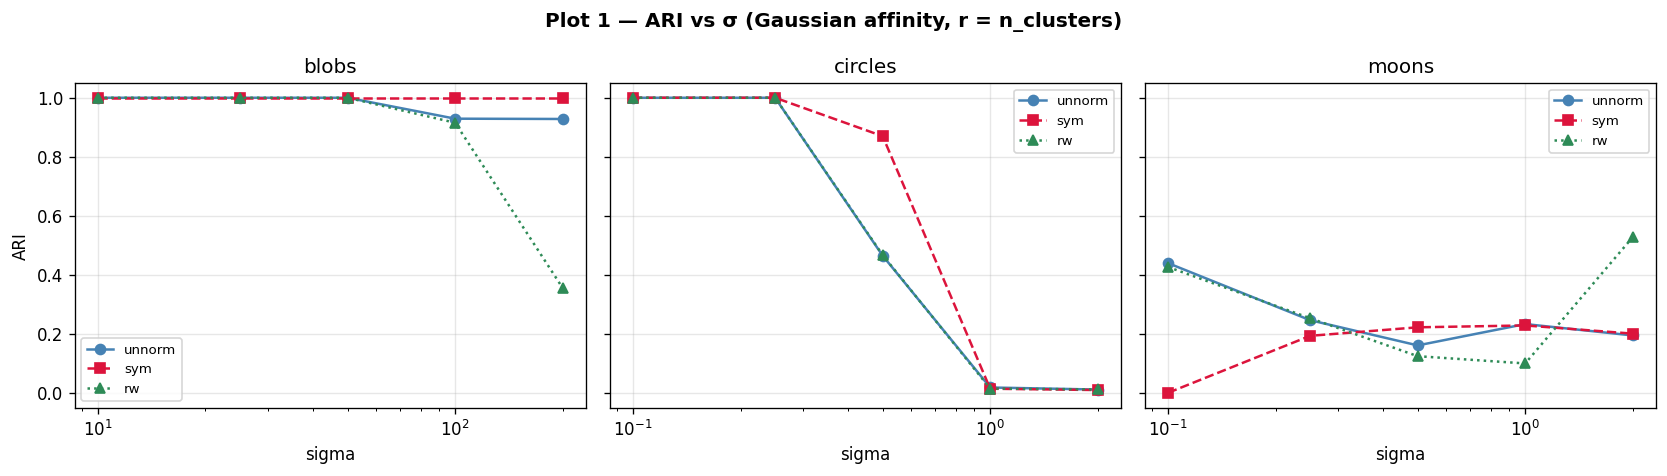

In [14]:
# Shared Laplacian style map (used in Plots 1–3)
lap_styles = {
    "unnorm": dict(color="steelblue",  linestyle="-",  marker="o", label="unnorm"),
    "sym":    dict(color="crimson",    linestyle="--", marker="s", label="sym"),
    "rw":     dict(color="seagreen",   linestyle=":",  marker="^", label="rw"),
}

# ── Plot 1: ARI vs sigma — Gaussian affinity ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Plot 1 — ARI vs σ (Gaussian affinity, r = n_clusters)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name = ds["name"]
    q       = ds["n_clusters"]
    subset  = df[(df["dataset"] == ds_name) &
                 (df["affinity"] == "gaussian") &
                 (df["rank_r"]   == q)]

    for lap, style in lap_styles.items():
        pts = subset[subset["laplacian"] == lap].groupby("sigma")["ari"].max()
        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.set_title(ds_name)
    ax.set_xlabel("sigma")
    ax.set_xscale("log")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ARI")
plt.tight_layout()
plt.show()

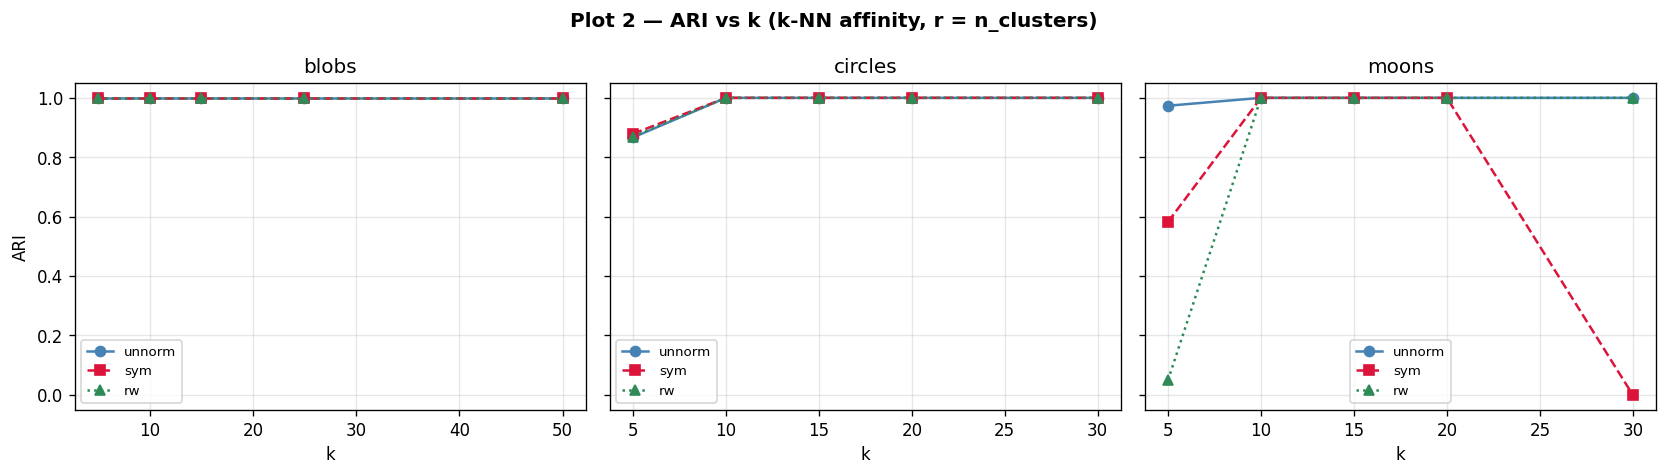

In [15]:
# ── Plot 2: ARI vs k — k-NN affinity ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Plot 2 — ARI vs k (k-NN affinity, r = n_clusters)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name = ds["name"]
    q       = ds["n_clusters"]
    subset  = df[(df["dataset"] == ds_name) &
                 (df["affinity"] == "knn") &
                 (df["rank_r"]   == q)]

    for lap, style in lap_styles.items():
        pts = subset[subset["laplacian"] == lap].groupby("k")["ari"].max()
        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.set_title(ds_name)
    ax.set_xlabel("k")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ARI")
plt.tight_layout()
plt.show()

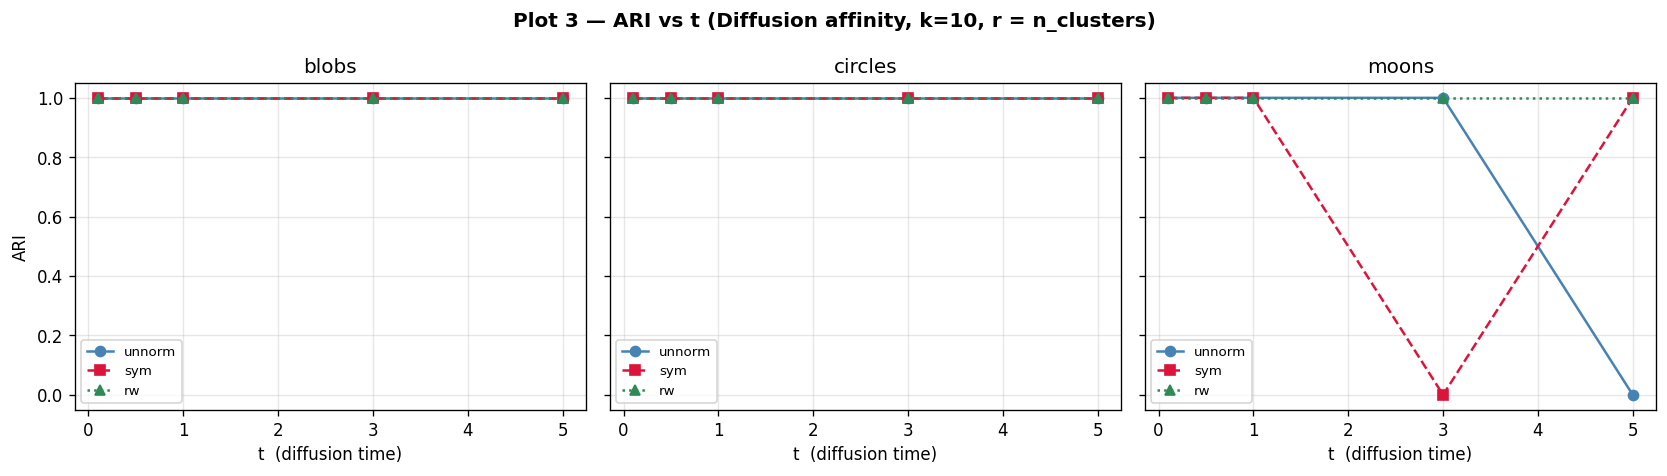

In [16]:
# ── Plot 3: ARI vs t — Diffusion affinity ─────────────────────────────────────
# Fix k = 10 as a reasonable default; revisit after reviewing Plot 2.
DEFAULT_K_DIFF = 10

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle(f"Plot 3 — ARI vs t (Diffusion affinity, k={DEFAULT_K_DIFF}, r = n_clusters)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name = ds["name"]
    q       = ds["n_clusters"]
    subset  = df[(df["dataset"] == ds_name) &
                 (df["affinity"] == "diffusion") &
                 (df["k"]        == DEFAULT_K_DIFF) &
                 (df["rank_r"]   == q)]

    for lap, style in lap_styles.items():
        pts = subset[subset["laplacian"] == lap].groupby("t")["ari"].max()
        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.set_title(ds_name)
    ax.set_xlabel("t  (diffusion time)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ARI")
plt.tight_layout()
plt.show()

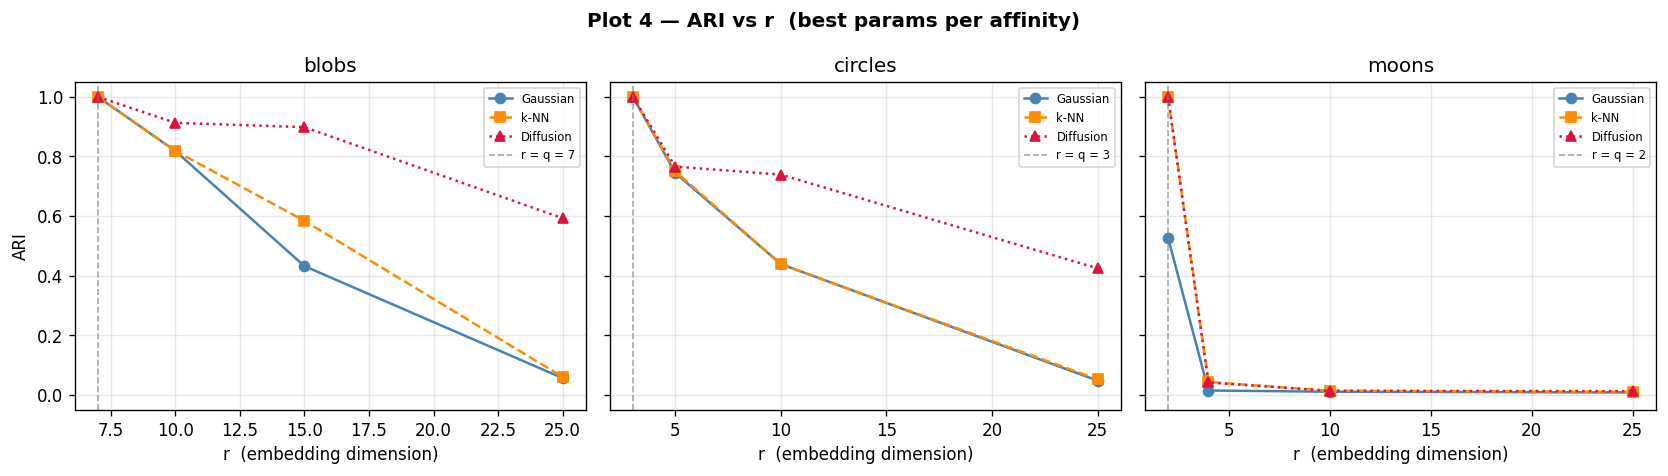

In [17]:
# ── Plot 4: ARI vs r — all three affinities compared ─────────────────────────
# For each affinity, fix best (Laplacian + sigma/k/t) from Tables 1-2 and sweep r.
# A vertical dashed line marks the true number of clusters q.

aff_styles = {
    "gaussian":  dict(color="steelblue",  linestyle="-",  marker="o", label="Gaussian"),
    "knn":       dict(color="darkorange", linestyle="--", marker="s", label="k-NN"),
    "diffusion": dict(color="crimson",    linestyle=":",  marker="^", label="Diffusion"),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Plot 4 — ARI vs r  (best params per affinity)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name   = ds["name"]
    q         = ds["n_clusters"]
    subset_ds = df[df["dataset"] == ds_name]

    for aff, style in aff_styles.items():
        sub = subset_ds[subset_ds["affinity"] == aff]
        if len(sub) == 0 or sub["ari"].isna().all():
            continue

        # Best Laplacian for this affinity on this dataset
        best_lap = sub.groupby("laplacian")["ari"].max().idxmax()
        sub_lap  = sub[sub["laplacian"] == best_lap]

        if aff == "gaussian":
            best_sigma = sub_lap.groupby("sigma")["ari"].max().idxmax()
            pts = (sub_lap[sub_lap["sigma"] == best_sigma]
                   .groupby("rank_r")["ari"].max())
        elif aff == "knn":
            sub_k  = sub_lap[sub_lap["k"] != "N/A"]
            best_k = sub_k.groupby("k")["ari"].max().idxmax()
            pts = (sub_lap[sub_lap["k"] == best_k]
                   .groupby("rank_r")["ari"].max())
        else:  # diffusion
            sub_k  = sub_lap[sub_lap["k"] != "N/A"]
            best_k = sub_k.groupby("k")["ari"].max().idxmax()
            best_t = (sub_lap[sub_lap["k"] == best_k]
                      .groupby("t")["ari"].max().idxmax())
            pts = (sub_lap[(sub_lap["k"] == best_k) & (sub_lap["t"] == best_t)]
                   .groupby("rank_r")["ari"].max())

        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.axvline(x=q, color="grey", linestyle="--", linewidth=1, alpha=0.7,
               label=f"r = q = {q}")
    ax.set_title(ds_name)
    ax.set_xlabel("r  (embedding dimension)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ARI")
plt.tight_layout()
plt.show()

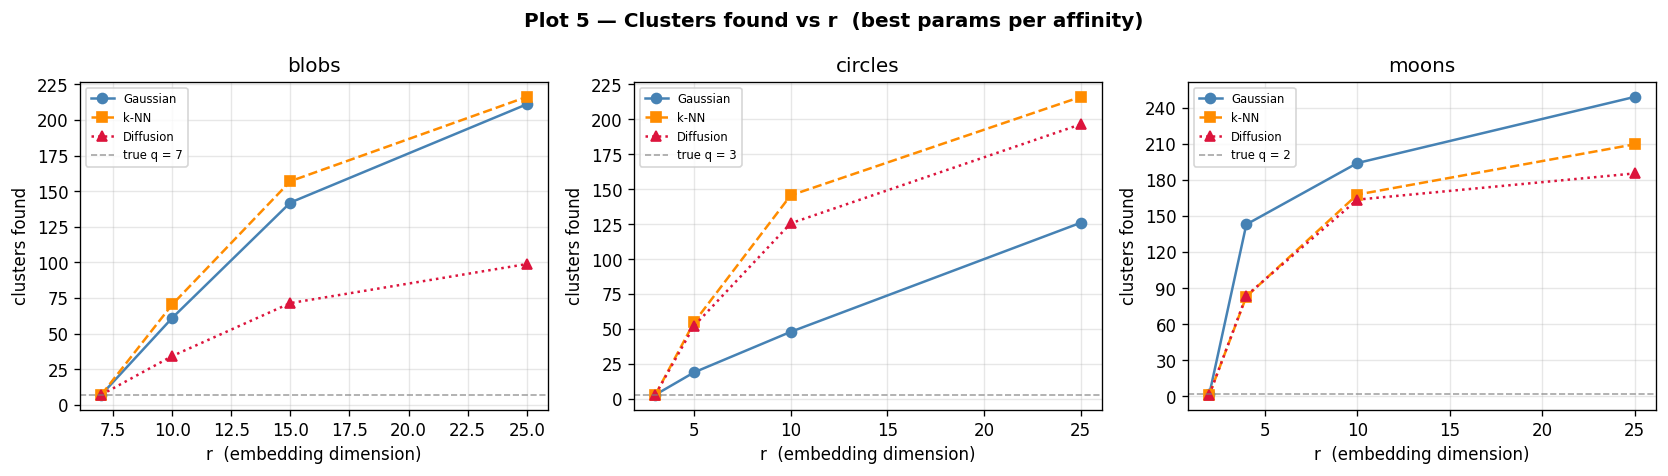

In [18]:
# ── Plot 5: Number of clusters found vs r ─────────────────────────────────────
# Same layout as Plot 4 but y-axis is n_clusters_found.
# A horizontal dashed line marks the ground-truth cluster count q.

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Plot 5 — Clusters found vs r  (best params per affinity)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name   = ds["name"]
    q         = ds["n_clusters"]
    subset_ds = df[df["dataset"] == ds_name]

    for aff, style in aff_styles.items():
        sub = subset_ds[subset_ds["affinity"] == aff]
        if len(sub) == 0 or sub["ari"].isna().all():
            continue

        best_lap = sub.groupby("laplacian")["ari"].max().idxmax()
        sub_lap  = sub[sub["laplacian"] == best_lap]

        if aff == "gaussian":
            best_sigma = sub_lap.groupby("sigma")["ari"].max().idxmax()
            pts = (sub_lap[sub_lap["sigma"] == best_sigma]
                   .groupby("rank_r")["n_clusters_found"].mean())
        elif aff == "knn":
            sub_k  = sub_lap[sub_lap["k"] != "N/A"]
            best_k = sub_k.groupby("k")["ari"].max().idxmax()
            pts = (sub_lap[sub_lap["k"] == best_k]
                   .groupby("rank_r")["n_clusters_found"].mean())
        else:  # diffusion
            sub_k  = sub_lap[sub_lap["k"] != "N/A"]
            best_k = sub_k.groupby("k")["ari"].max().idxmax()
            best_t = (sub_lap[sub_lap["k"] == best_k]
                      .groupby("t")["ari"].max().idxmax())
            pts = (sub_lap[(sub_lap["k"] == best_k) & (sub_lap["t"] == best_t)]
                   .groupby("rank_r")["n_clusters_found"].mean())

        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.axhline(y=q, color="grey", linestyle="--", linewidth=1, alpha=0.7,
               label=f"true q = {q}")
    ax.set_title(ds_name)
    ax.set_xlabel("r  (embedding dimension)")
    ax.set_ylabel("clusters found")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 11: Additional Visualisations

Add affinity heatmaps, row profiles, eigenvalue spectra, and eigenvector quality
diagnostics here after reviewing initial results.

---
## Section 12: Noise Robustness Experiments

The full parameter grid from Section 7 is swept independently at each noise level.
Additive Gaussian noise with increasing σ is applied to the raw features via `add_gaussian_noise`.

- **Table N1** — best parameters and ARI at every (noise level, dataset, affinity).
- **Plot N1** — best achievable ARI vs σ (maximised over all parameters).
- **Plot N2** — |k_found − k_true| at the best-ARI configuration vs σ.

In [19]:
from data.generators import add_gaussian_noise

# Per-dataset noise levels — blobs live in 5000-D so meaningful perturbations
# are much larger in absolute scale than for the 2-D datasets.
noise_levels_by_ds = {
    "blobs":   [5, 25, 50],
    "circles": [0.1, 0.25, 0.5],
    "moons":   [0.1, 0.25, 0.5],
}

noise_grand_total = sum(
    len(noise_levels_by_ds[ds["name"]]) * (
        len(param_grids[ds["name"]]["sigma_values"]) * len(param_grids[ds["name"]]["laplacian_types"]) * len(param_grids[ds["name"]]["r_values"])
        + len(param_grids[ds["name"]]["k_values"]) * len(param_grids[ds["name"]]["sigma_values"]) * len(param_grids[ds["name"]]["laplacian_types"]) * len(param_grids[ds["name"]]["r_values"])
        + len(param_grids[ds["name"]]["k_values"]) * len(param_grids[ds["name"]]["sigma_values"]) * len(param_grids[ds["name"]]["t_values"]) * len(param_grids[ds["name"]]["laplacian_types"]) * len(param_grids[ds["name"]]["r_values"])
    )
    for ds in datasets
)
print(f"Noise sweep: {noise_grand_total} total runs across all datasets and noise levels")
for ds in datasets:
    name    = ds["name"]
    g       = param_grids[name]
    n_sigma = len(g["sigma_values"])
    n_lap   = len(g["laplacian_types"])
    n_r     = len(g["r_values"])
    n_per_ds = (n_sigma * n_lap * n_r
                + len(g["k_values"]) * n_sigma * n_lap * n_r
                + len(g["k_values"]) * n_sigma * len(g["t_values"]) * n_lap * n_r)
    print(f"  {name:>10s}: noise levels={noise_levels_by_ds[name]},  "
          f"{len(noise_levels_by_ds[name])} × {n_per_ds} = {len(noise_levels_by_ds[name]) * n_per_ds} runs")

Noise sweep: 16740 total runs across all datasets and noise levels
       blobs: noise levels=[5, 25, 50],  3 × 1860 = 5580 runs
     circles: noise levels=[0.1, 0.25, 0.5],  3 × 1860 = 5580 runs
       moons: noise levels=[0.1, 0.25, 0.5],  3 × 1860 = 5580 runs


In [20]:
noise_results = []

base_X = {"blobs": X_blobs, "circles": X_circles, "moons": X_moons}
base_y = {"blobs": y_blobs, "circles": y_circles, "moons": y_moons}

def _record(noise_std, name, aff, sigma, k, t, r, lap, outcome):
    base = {"noise_std": noise_std, "dataset": name, "affinity": aff,
            "sigma": sigma, "k": k, "t": t, "rank_r": r, "laplacian": lap}
    if isinstance(outcome, Exception):
        noise_results.append({**base, "ari": np.nan, "n_clusters_found": np.nan,
                               "delta_k": np.nan, "spectral_gap": np.nan,
                               "laplacian_is_psd": np.nan,
                               "laplacian_min_eigenvalue": np.nan,
                               "error": str(outcome)})
    else:
        noise_results.append({**base, **outcome})

for ds in tqdm(datasets, desc="Datasets"):
    name   = ds["name"]
    y      = base_y[name]
    g      = param_grids[name]
    X_base = base_X[name]

    for noise_std in tqdm(noise_levels_by_ds[name], desc=name, leave=False):
        X_noisy = add_gaussian_noise(X_base, noise_std=noise_std, seed=0)
        D = dist_mat(X_noisy)

        sigma_values    = g["sigma_values"]
        k_values        = g["k_values"]
        t_values        = g["t_values"]
        r_values        = g["r_values"]
        laplacian_types = g["laplacian_types"]

        # ── Gaussian ──────────────────────────────────────────────────────────
        for sigma in sigma_values:
            A = affinity_gaussian(D, sigma)
            for lap in laplacian_types:
                for r in r_values:
                    try:
                        _record(noise_std, name, "gaussian", sigma, "N/A", "N/A", r, lap,
                                run_single(A, lap, r, y))
                    except Exception as e:
                        _record(noise_std, name, "gaussian", sigma, "N/A", "N/A", r, lap, e)

        # ── k-NN ──────────────────────────────────────────────────────────────
        for k in k_values:
            for sigma in sigma_values:
                A = affinity_knn(D, k, sigma)
                for lap in laplacian_types:
                    for r in r_values:
                        try:
                            _record(noise_std, name, "knn", sigma, k, "N/A", r, lap,
                                    run_single(A, lap, r, y))
                        except Exception as e:
                            _record(noise_std, name, "knn", sigma, k, "N/A", r, lap, e)

        # ── Diffusion ─────────────────────────────────────────────────────────
        for k in k_values:
            for sigma in sigma_values:
                for t in t_values:
                    A = affinity_diffusion(D, k, sigma, t)
                    for lap in laplacian_types:
                        for r in r_values:
                            try:
                                _record(noise_std, name, "diffusion", sigma, k, t, r, lap,
                                        run_single(A, lap, r, y))
                            except Exception as e:
                                _record(noise_std, name, "diffusion", sigma, k, t, r, lap, e)

df_noise = pd.DataFrame(noise_results)
print(f"\nNoise sweep complete: {len(df_noise)} rows")
df_noise.head()

Datasets:   0%|          | 0/3 [00:00<?, ?it/s]

blobs:   0%|          | 0/3 [00:00<?, ?it/s]

circles:   0%|          | 0/3 [00:00<?, ?it/s]

moons:   0%|          | 0/3 [00:00<?, ?it/s]


Noise sweep complete: 16740 rows


,noise_std,dataset,affinity,sigma,k,t,rank_r,laplacian,ari,n_clusters_found,delta_k,spectral_gap,laplacian_is_psd,laplacian_min_eigenvalue
0,5.0,blobs,gaussian,10.0,N/A,N/A,7,unnorm,0.000189,600,593,0.0,True,0.0
1,5.0,blobs,gaussian,10.0,N/A,N/A,10,unnorm,0.000189,600,593,0.0,True,0.0
2,5.0,blobs,gaussian,10.0,N/A,N/A,15,unnorm,0.000189,600,593,0.0,True,0.0
3,5.0,blobs,gaussian,10.0,N/A,N/A,25,unnorm,0.000189,600,593,0.0,True,0.0
4,5.0,blobs,gaussian,10.0,N/A,N/A,7,sym,0.000189,600,593,0.0,True,0.0


TABLE N1: Best parameters and ARI at each noise level

=== BLOBS ===

  gaussian:
    noise_std=5: ARI=1.000  [σ=50, r=7, lap=unnorm]
    noise_std=25: ARI=0.506  [σ=200, r=7, lap=unnorm]
    noise_std=50: ARI=0.019  [σ=200, r=15, lap=rw]

  knn:
    noise_std=5: ARI=1.000  [σ=100, k=5, r=7, lap=unnorm]
    noise_std=25: ARI=0.767  [σ=200, k=25, r=7, lap=unnorm]
    noise_std=50: ARI=0.023  [σ=200, k=5, r=7, lap=unnorm]

  diffusion:
    noise_std=5: ARI=1.000  [σ=100, k=5, t=0.1, r=7, lap=unnorm]
    noise_std=25: ARI=0.784  [σ=100, k=5, t=5, r=25, lap=unnorm]
    noise_std=50: ARI=0.429  [σ=200, k=25, t=5, r=7, lap=unnorm]

=== CIRCLES ===

  gaussian:
    noise_std=0.1: ARI=1.000  [σ=0.1, r=3, lap=unnorm]
    noise_std=0.25: ARI=0.991  [σ=0.1, r=3, lap=sym]
    noise_std=0.5: ARI=0.319  [σ=0.1, r=25, lap=rw]

  knn:
    noise_std=0.1: ARI=1.000  [σ=0.1, k=10, r=3, lap=unnorm]
    noise_std=0.25: ARI=1.000  [σ=0.1, k=5, r=3, lap=unnorm]
    noise_std=0.5: ARI=0.349  [σ=0.1, k=20, r=2

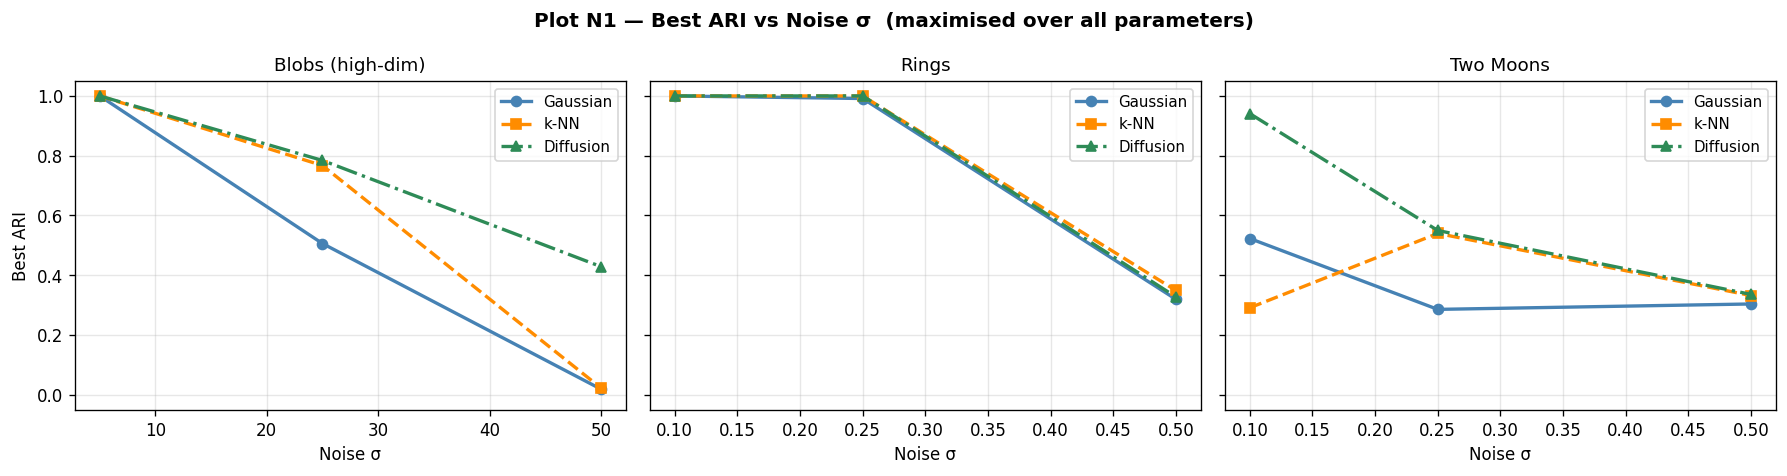

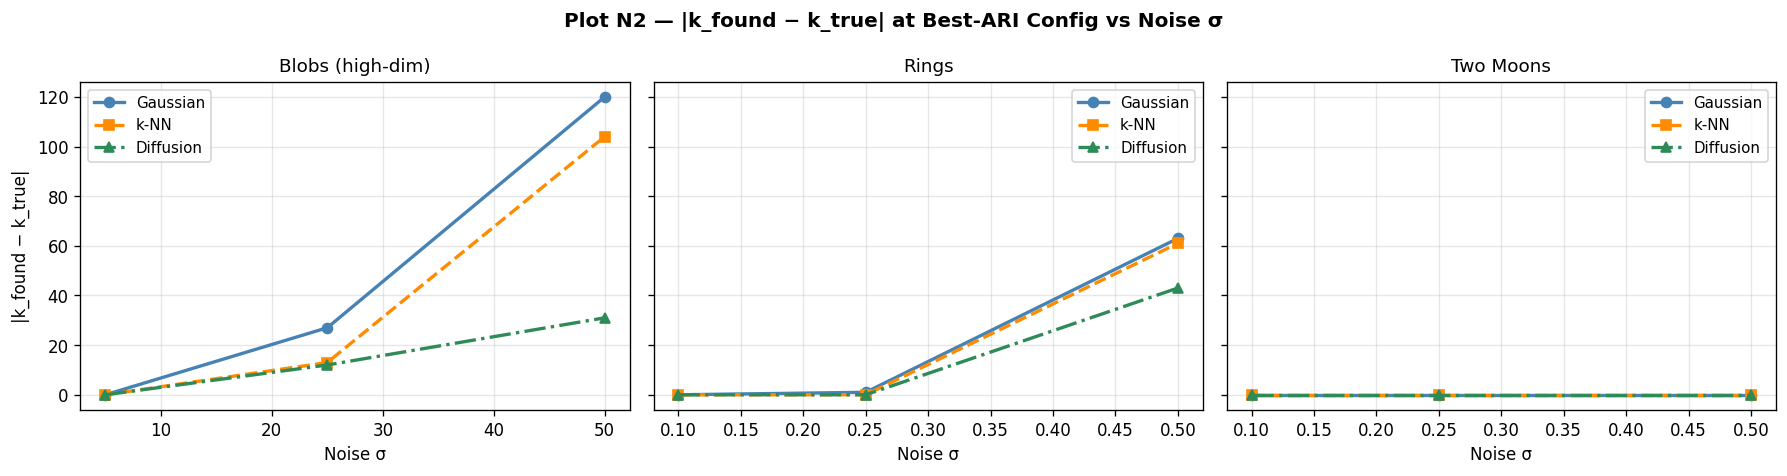

In [21]:
noise_aff_styles = {
    "gaussian":  dict(color="steelblue",  marker="o", linestyle="-",  label="Gaussian"),
    "knn":       dict(color="darkorange", marker="s", linestyle="--", label="k-NN"),
    "diffusion": dict(color="seagreen",   marker="^", linestyle="-.", label="Diffusion"),
}
ds_titles = {"blobs": "Blobs (high-dim)", "circles": "Rings", "moons": "Two Moons"}

# ── Table N1: Best params at each noise level ─────────────────────────────────
print("TABLE N1: Best parameters and ARI at each noise level")
print("=" * 72)
for ds_name in ["blobs", "circles", "moons"]:
    print(f"\n=== {ds_name.upper()} ===")
    for aff in ["gaussian", "knn", "diffusion"]:
        sub = df_noise[(df_noise["dataset"] == ds_name) & (df_noise["affinity"] == aff)]
        if sub.empty or sub["ari"].isna().all():
            continue
        print(f"\n  {aff}:")
        for ns in noise_levels_by_ds[ds_name]:
            lvl = sub[sub["noise_std"] == ns].dropna(subset=["ari"])
            if lvl.empty:
                continue
            best = lvl.loc[lvl["ari"].idxmax()]
            k_str = f"k={int(best['k'])}" if best.get("k") not in ("N/A", None) else ""
            t_str = f"t={best['t']:.2g}"  if best.get("t") not in ("N/A", None) else ""
            parts = [f"σ={best['sigma']:.3g}", k_str, t_str,
                     f"r={int(best['rank_r'])}", f"lap={best['laplacian']}"]
            print(f"    noise_std={ns}: ARI={best['ari']:.3f}  "
                  f"[{', '.join(p for p in parts if p)}]")

# ── Plot N1: Best ARI vs noise σ ──────────────────────────────────────────────
best_per_noise = (df_noise.dropna(subset=["ari"])
                          .groupby(["noise_std", "dataset", "affinity"])["ari"]
                          .max()
                          .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Plot N1 — Best ARI vs Noise σ  (maximised over all parameters)",
             fontsize=12, fontweight="bold")

for ax, ds_name in zip(axes, ["blobs", "circles", "moons"]):
    for aff, style in noise_aff_styles.items():
        sub = best_per_noise[(best_per_noise["dataset"] == ds_name) &
                             (best_per_noise["affinity"] == aff)]
        if sub.empty:
            continue
        ax.plot(sub["noise_std"], sub["ari"], **style, linewidth=2, markersize=6)
    ax.set_title(ds_titles[ds_name], fontsize=11)
    ax.set_xlabel("Noise σ", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("Best ARI", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Plot N2: |delta_k| at best-ARI config vs noise σ ─────────────────────────
best_idx  = (df_noise.dropna(subset=["ari"])
                     .groupby(["noise_std", "dataset", "affinity"])["ari"]
                     .idxmax())
best_rows = df_noise.loc[best_idx].reset_index(drop=True)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig2.suptitle("Plot N2 — |k_found − k_true| at Best-ARI Config vs Noise σ",
              fontsize=12, fontweight="bold")

for ax, ds_name in zip(axes2, ["blobs", "circles", "moons"]):
    for aff, style in noise_aff_styles.items():
        sub = best_rows[(best_rows["dataset"] == ds_name) &
                        (best_rows["affinity"] == aff)]
        if sub.empty:
            continue
        ax.plot(sub["noise_std"], sub["delta_k"], **style, linewidth=2, markersize=6)
    ax.set_title(ds_titles[ds_name], fontsize=11)
    ax.set_xlabel("Noise σ", fontsize=10)
    if ax is axes2[0]:
        ax.set_ylabel("|k_found − k_true|", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
noise_output_path = "diffusion_kernel_noise_results_v3.csv"
df_noise.to_csv(noise_output_path, index=False)
print(f"Noise results saved: {df_noise.shape[0]} rows → {noise_output_path}")

Noise results saved: 16740 rows → diffusion_kernel_noise_results_v3.csv


---
## Section 13: Save Results

In [23]:
output_path = "diffusion_kernel_experiment_results_v3.csv"
df.to_csv(output_path, index=False)
print(f"Results saved: {df.shape[0]} rows × {df.shape[1]} columns → {output_path}")

Results saved: 5580 rows × 15 columns → diffusion_kernel_experiment_results_v3.csv
